PYTHON: /media/monte_share/conda_envs/dataproc/bin/python
LD_LIBRARY_PATH: None
CONDA_PREFIX: /media/monte_share/conda_envs/dataproc


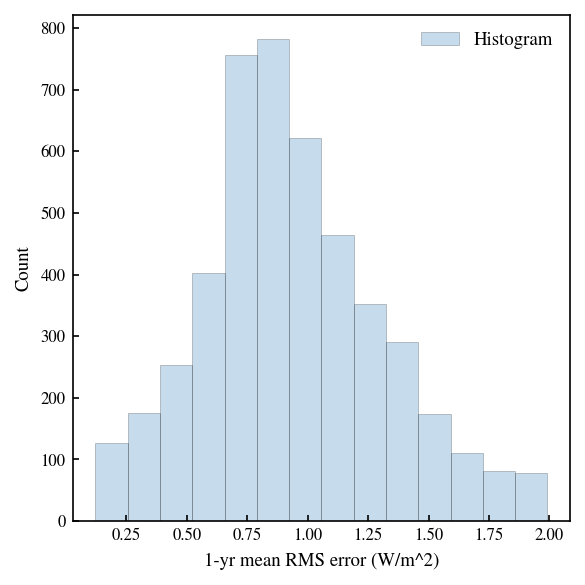

In [1]:
import sys, os
import numpy as np
import SpaceBalls.output_database_manager as db_manager
from SpaceBalls.plotter import Plotter
from SpaceBalls.postproc_EEI_estimation import generate_constellation_stacking_animations
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series
from SpaceBalls.utils import normal_smoother
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR
import time

RMS_lim = 2
window_days = 365
window_name = str(window_days) + '-day'

EEI_name = "EEI_truth_1"
#TODO: fix code duplication with compute_rolling_avg_error_time_series
full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))
mid_day_jd_array = get_mid_day_jd_array(EEI_name)
EEI_time_series_180x360 = get_true_EEI_time_series(EEI_name, 360, 180)

EEI_smooth_true = normal_smoother(EEI_time_series_180x360, full_jd_array, window_width_days=window_days, 
                                out_length_mode='same_with_nans')
EEI_smooth_true_coarse = np.interp(mid_day_jd_array, full_jd_array, EEI_smooth_true)
# end TODO

error_RMS_column_name = 'error_RMS_'+str(window_days)+'_day_avg'
results = db_manager.retrieve_column('EEI_postproc_results_table', error_RMS_column_name)

keys = db_manager.retrieve_column_from_condition('EEI_postproc_results_table', 'estimation_key',
                                                    error_RMS_column_name, 0.15, '<')
#satellites = db_manager.retrieve_column_from_condition('config_table', 'satellites', 'estimation_key')

results = db_manager.retrieve_columns_from_condition('EEI_postproc_results_table',
                                                     'config_table',
                                                     error_RMS_column_name,
                                                     'satellites',
                                                     error_RMS_column_name,
                                                     RMS_lim, 
                                                     'estimation_key',
                                                     '<')

all_keys = [row[0] for row in results]
all_rms = [row[1] for row in results]
Plotter.plot_histogram(all_rms, xlabel='1-yr mean RMS error (W/m^2)', normalized=False)

db_manager.conn.close()




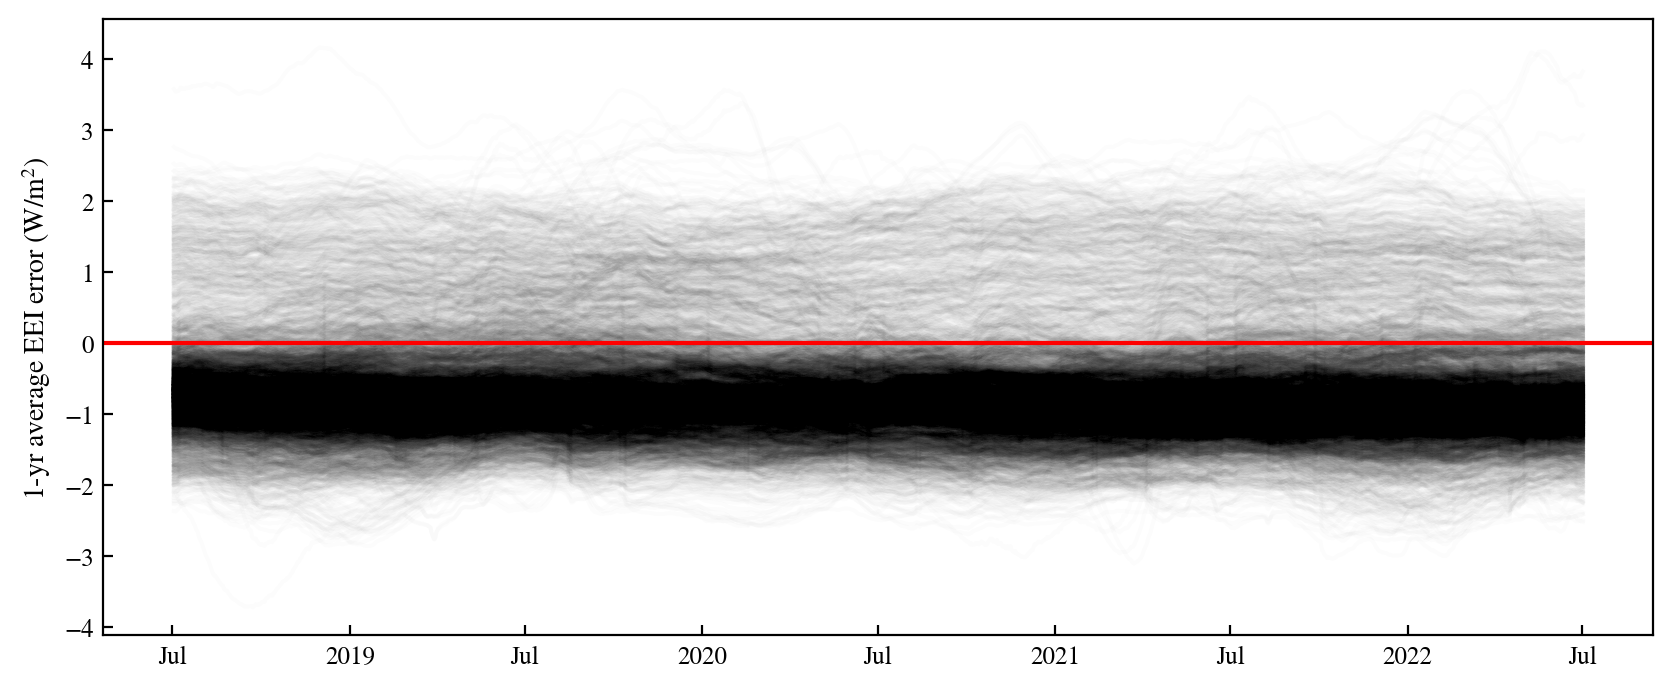

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

dates = Plotter.jd_to_datetime(mid_day_jd_array)
fig, ax = plt.subplots(figsize=(10, 4), dpi=200)

for row in results:
    key, rms, constellation_name = row
    fname = os.path.join(MEDIA_DIR, 'EEI_estimations', window_name+'_avg_error_time_series',
                                             key+'.npy')
    if os.path.exists(fname):
        error_time_series = np.load(fname)
        ax.plot(dates, error_time_series, color='k', alpha=0.01)

ax.axhline(0, color='red')
ax.set_ylabel('1-yr average EEI error (W/m$^2$)')
locator = mdates.AutoDateLocator() # minticks=3, maxticks=7)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

In [ ]:
for row in results:
    key, rms, constellation_name = row
    error_time_series = np.load(os.path.join(MEDIA_DIR, 'EEI_estimations', window_name+'_avg_error_time_series',
                                             key+'.npy'))
    EEI_smooth_estimated = error_time_series + EEI_smooth_true_coarse

    Plotter.plot_time_series(mid_day_jd_array,
                        {'True EEI ('+window_name+' avg.)': EEI_smooth_true_coarse,
                        'Estimated EEI ('+window_name+' avg.)': EEI_smooth_estimated},
                        f_width=2.5, f_height=0.5,
                        ylabel='Net TOA flux (W/m$^2$)',
                        y_scatter_dict={'$\phi(t)$ (W/m$^2$)': (full_jd_array, EEI_time_series_180x360)},
                        scatter_alpha=0.007,
                        out_dir=os.path.join(MEDIA_DIR, 'figures', constellation_name),
                        file_name='EEI_estimate_'+window_name,
                        title=constellation_name + ' - RMS: ' + f"{rms:.{4}f}" + 'W/m$^2$')


In [ ]:
from SpaceBalls.postproc_EEI_estimation import generate_constellation_stacking_animations

constellation_name = 'sc_C2|sc_D1|sc_I2'
generate_constellation_stacking_animations('case_5_years', sc_names=constellation_name.split("|"), 
                                            constellation_tag=constellation_name,
                                            n_days=365, n_lon=360, n_lat=180, frame='SFF')

In [ ]:
for row in results:
    key, rms, constellation_name = row
    generate_constellation_stacking_animations('case_5_years', sc_names=constellation_name.split("|"), 
                                            constellation_tag=constellation_name,
                                            n_days=365, n_lon=360, n_lat=180, frame='SFF')